In [2]:
# imports
import numpy as np
import random
import threading
import requests
import json
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.models import Model
import chess
import chess.pgn
from tensorflow.keras.callbacks import Callback
from tqdm import tqdm
import time 
from concurrent.futures import ThreadPoolExecutor
import keras

In [2]:
# helper functions

# converts lichess's FEN notation to a 8x8 x 12 tensor
def board_to_tensor(board):
    tensor = np.zeros((8, 8, 12), dtype=np.float32) # essentially a 12 stack of 8x8 chess boards
    piece_to_index = { # encode pieces as numbers
        chess.PAWN: 0,
        chess.KNIGHT: 1,
        chess.BISHOP: 2,
        chess.ROOK: 3,
        chess.QUEEN: 4,
        chess.KING: 5,
    }
    for square, piece in board.piece_map().items(): # place each piece on the right square on the right board
        row = 7 - (square // 8)
        col = square % 8
        idx = piece_to_index[piece.piece_type]
        if piece.color == chess.BLACK: #white pieces occupy boards 0-5, black pieces occupy boards 6-11
            idx += 6
        tensor[row, col, idx] = 1
    return tensor


def move_to_index(move):
    return move.from_square * 64 + move.to_square


# fill an array with FEN notation games
def parse_pgn(pgn_file, max_games):
    games = []
    with open(pgn_file) as f:
        for game in range(max_games):
            game = chess.pgn.read_game(f)
            if game is None:
                break
            games.append(game)
    return games


In [7]:
# import lichess games

training_games = parse_pgn("lichess_elite_2022-03.pgn", max_games = 50000)
testing_games = parse_pgn("lichess_elite_2022-04.pgn", max_games = 2000)
print(f"games loaded")

games loaded


In [ ]:
# create labels using players' next move

def convert(games):
    X = []  # Board tensors
    y = []  # Next move labels (as indices)
    currentGame = 0

    for game in games:
        board = game.board()  # start at the initial board position
        if currentGame % 1000 == 0:
            print(f"Processed {currentGame} / {len(games)} games")
        for move in game.mainline_moves():
            # sample 1/10th of the board state
            if random.random() < 0.1 and not board.is_game_over():
                board_tensor = board_to_tensor(board)
                move_index = move_to_index(move) #label it with the move that's about to be played.
                X.append(board_tensor)
                y.append(move_index)
            board.push(move)
        currentGame += 1

    X = np.array(X)
    y = np.array(y)
    return X, y

X_train, y_train = convert(training_games)
print(f"Training examples: {X_train.shape[0]} \n")

X_test, y_test = convert(testing_games)
print(f"Testing examples: {X_test.shape[0]} \n")

In [ ]:
# create labels using stockfish engine

# makes stockfish not throw errors
import sys
import asyncio
if sys.platform.startswith("win"):
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
import nest_asyncio
nest_asyncio.apply()


# get stockfish engine 
engine = chess.engine.SimpleEngine.popen_uci("stockfish/stockfish-windows-x86-64-sse41-popcnt.exe")

# convert games to training/testing examples, label each board state with best move from stockfish
def convert(games, engine):
    X = []  # Board tensors
    y = []  # Best move labels (as indices)
    currentGame = 0

    for game in games:
        board = game.board()  # start at the initial board position
        if currentGame % 500 == 0:
            print(f"processed {currentGame} / {len(games)} games")
        for move in game.mainline_moves():
            # use 1/10 of the board states in the game
            if random.random() < 0.1 and not board.is_game_over():
                try:
                    result = engine.analyse(board, chess.engine.Limit(time=0.01))
                    best_move = result['pv'][0] if 'pv' in result else None # get stockfish prediction
                    if best_move is not None:
                        board_tensor = board_to_tensor(board)
                        move_index = move_to_index(best_move) # label dataset with stockfish prediction
                        X.append(board_tensor)
                        y.append(move_index)
                except Exception as e:
                    print("Engine analysis failed:", e) # would otherwise break if computer accidentally turns off
            board.push(move)
        currentGame += 1
    
    X = np.array(X)
    y = np.array(y)
    return X, y

X_train, y_train = convert(training_games, engine)
print(f"Training examples: {X_train.shape[0]} \n")

X_test, y_test = convert(testing_games, engine)
print(f"Testing examples: {X_test.shape[0]} \n")

engine.quit()  # free stockfish engine

In [ ]:
#save datasets

#np.save("X_train_50000_nextmove.npy", X_train)
#np.save("y_train_50000_nextmove.npy", y_train)
#np.save("X_test_2000_nextmove.npy", X_test)
#np.save("y_test_2000_nextmove.npy", y_test)

np.save("X_train_50000_stockfish.npy", X_train)
np.save("y_train_50000_stockfish.npy", y_train)
np.save("X_test_2000_stockfish.npy", X_test)
np.save("y_test_2000_stockfish.npy", y_test)

In [ ]:
#load datasets

# X_train = np.load("X_train_50000_stockfish.npy")
# y_train = np.load("y_train_50000_stockfish.npy")
# X_test = np.load("X_test_2000_stockfish.npy")
# y_test = np.load("y_test_2000_stockfish.npy")

X_train = np.load("X_train_50000_nextmove.npy")
y_train = np.load("y_train_50000_nextmove.npy")
X_test = np.load("X_test_2000_nextmove.npy")
y_test = np.load("y_test_2000_nextmove.npy")

In [4]:
#creating model

def create_model():
    input_layer = Input(shape=(8, 8, 12))
    
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(input_layer)
    x = BatchNormalization()(x)

    # convolutional layers are excellent at learning spatial patterns
    for i in range(4):
        x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
        x = BatchNormalization()(x) # batch norm is a common pairing because they stabilize gradients and training
        x = Dropout(0.2)(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    # output: predict best move from 4096 classes
    output = Dense(4096, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), #use Adam optimizer 
    loss='sparse_categorical_crossentropy', # alternative to one-hot encoding that saves resources
    metrics=['accuracy']
)
    return model

model = create_model()

In [ ]:
# Train the model 

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test) # test model at every epoch with small test set
)

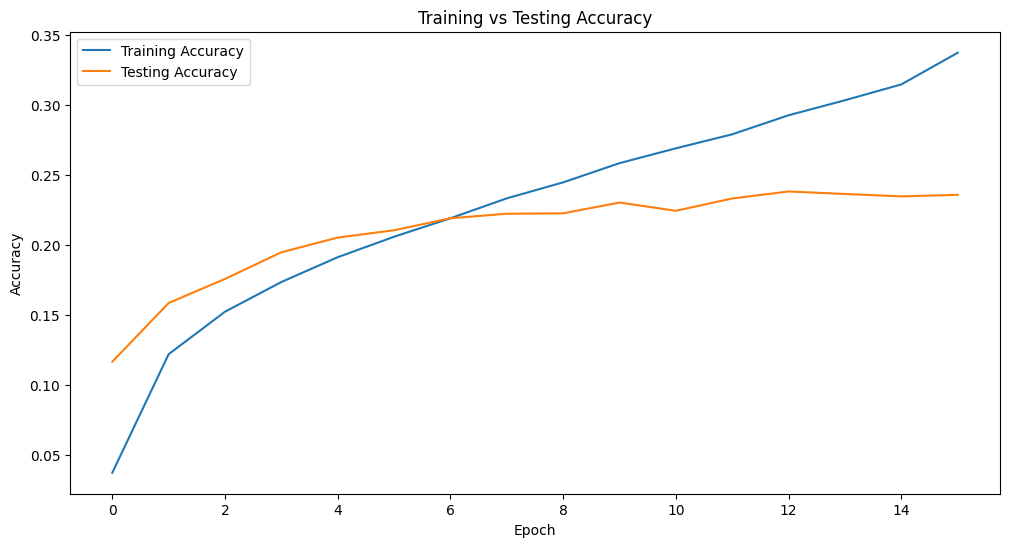

In [20]:
# plot train and test accuracy over time
import matplotlib.pyplot as plt

accuracy = [0.0373, 0.1219, 0.1522, 0.1734, 0.1911, 0.2057, 0.2189, 0.2331, 0.2445, 0.2582, 0.2688, 0.2788, 0.2924, 0.3031, 0.3144, 0.3370]
val_accuracy = [0.1165, 0.1584, 0.1756, 0.1946, 0.2051, 0.2103, 0.2189, 0.2221, 0.2224, 0.2301, 0.2242, 0.2330, 0.2380, 0.2362, 0.2345, 0.2356]

plt.figure(figsize=(12, 6))
plt.plot(accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.legend()

plt.savefig("accuracy_graph.png")

plt.show()

In [13]:
# run only test set
loss, accuracy = model.evaluate(X_test, y_test, batch_size=32)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

520/520 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.2321 - loss: 9.8602
Test Loss: 9.492789268493652
Test Accuracy: 0.23560555279254913


In [16]:
# functions to connect to lichess

TOKEN = "" #add your API token here        
BOT_ID = "" #add name of bot account here
HEADERS = {"Authorization": f"Bearer {TOKEN}"}
BASE_URL = "https://lichess.org"
game_colors = {}


#make educated guess
def make_best_move(game_id, board):

    move = choose_best_move(board)
    if move:
        #connect move to Lichess url
        uci_move = move.uci()
        url = f"{BASE_URL}/api/bot/game/{game_id}/move/{uci_move}"
        response = requests.post(url, headers=HEADERS)
        print(f"Played move {uci_move} \n") #print chosen move to console
    else: #end of game - checkmate or draw
        print("No legal moves available!")
        
        
#choose a random legal move and play it
def make_random_move(game_id, board):
    legal_moves = list(board.legal_moves)
    
    if legal_moves:
        #connect move to Lichess url
        move = choose_random_move(board)
        uci_move = move.uci()
        url = f"{BASE_URL}/api/bot/game/{game_id}/move/{uci_move}"
        response = requests.post(url, headers=HEADERS)
        print(f"Played move {uci_move} \n") #print chosen move to console
    else: #end of game - checkmate or draw
        print("No legal moves available!")
        

def accept_challenge(challenge_id):
    url = f"{BASE_URL}/api/challenge/{challenge_id}/accept"
    response = requests.post(url, headers=HEADERS)
    print("got challenge")
    
    if response.status_code == 200: # code 200 = good
        print(f"Accepted challenge: {challenge_id}")
    else: # code 404 = not found
        print(f"Failed to accept challenge: {challenge_id} - {response.text}")

# stream game events for a given game
# uses python-chess to maintain the board state
def handle_game(game_id):

    url = f"{BASE_URL}/api/bot/game/stream/{game_id}"
    response = requests.get(url, headers=HEADERS, stream=True)
    board = chess.Board()
    
    for line in response.iter_lines(decode_unicode=True):
        if line:
            try:
                event = json.loads(line)
            except Exception as e:
                print("Error parsing line:", line)
                continue
            
            # when the game starts, record white or black
            if event.get("type") == "gameFull":
                
                white_id = event.get("white", {}).get("id")
                black_id = event.get("black", {}).get("id")
                my_color = "white" if white_id.lower() == BOT_ID.lower() else "black"
                game_colors[game_id] = my_color
                print(f"Game {game_id} started. My color: {my_color}")
                # process initial moves if there are any
                moves_str = event.get("state", {}).get("moves", "")
                if moves_str:
                    for move in moves_str.split():
                        board.push_uci(move)
            
            # update board state with new moves
            elif event.get("type") == "gameState":
                moves_str = event.get("moves", "")
                board = chess.Board()  # reset board and replay moves
                if moves_str:
                    for move in moves_str.split():
                        board.push_uci(move)
            
            # check if it's our turn
            my_color = game_colors.get(game_id)
            # in python-chess, board.turn == True means whites turn
            if my_color:
                if (board.turn and my_color == "white") or (not board.turn and my_color == "black"):
                    make_best_move(game_id, board)

# listens to the Lichess event stream for incoming challenges
# accepts any challenges
def event_stream():

    url = f"{BASE_URL}/api/stream/event"
    response = requests.get(url, headers=HEADERS, stream=True)
    
    for line in response.iter_lines(decode_unicode=True):
        if line:
            try:
                event = json.loads(line)
            except Exception as e:
                print("Error parsing event stream line:", line)
                continue
            
            event_type = event.get("type")
            
            if event_type == "challenge":
                challenge_id = event["challenge"]["id"]
                print(f"Received challenge: {challenge_id}")
                accept_challenge(challenge_id)
            
            elif event_type == "gameStart":
                game_id = event["game"]["id"]
                print(f"Game started: {game_id}")
                # launch a separate thread for handling the game.
                threading.Thread(target=handle_game, args=(game_id,), daemon=True).start()


In [ ]:
# start the lichess bot and run it in the background
threading.Thread(target=event_stream, daemon=True).start()
print("Lichess bot is running. Waiting for challenges...")

In [18]:
#model saves

#model.save("chess_model1.keras")
#model.save("chess_model2.keras") 
#model.save("chess_model3.keras") #50k training games, 8 epochs, 10 nn layers, 16% acc
#model.save("chess_model4.keras") #50k training games, 20 epochs, 4 x 512 layers, 34% train acc, 24% test acc
model.save("chess_model5.keras") #16 epochs, same as above, graph accurate

In [14]:
model = keras.models.load_model("chess_model5.keras")

In [15]:
# simulate games

@tf.function # for parallelism
def predict_board(board_tensor):
    return model(board_tensor)

def choose_best_move(board):
    # convert current board state to tensor 
    board_tensor = board_to_tensor(board)
    board_tensor = np.expand_dims(board_tensor, axis=0)
    
    board_tensor_tf = tf.convert_to_tensor(board_tensor)
    
    predictions = predict_board(board_tensor_tf)[0].numpy()  # 4096 possible 
    
    legal_moves = list(board.legal_moves)
    if not legal_moves:
        return None  # no legal moves available = game ended
    
    best_move = None
    best_prob = -1
    for move in legal_moves:
        idx = move_to_index(move)
        prob = predictions[idx]
        if prob > best_prob:
            best_prob = prob
            best_move = move
            
    return best_move


def choose_random_move(board):
    moves = list(board.legal_moves)
    return random.choice(moves)


def simulate_game(white_move_func, black_move_func):
    board = chess.Board()
    while not board.is_game_over():
        if board.turn == chess.WHITE:
            move = white_move_func(board)
        else:
            move = black_move_func(board)
        board.push(move)
    return board.result()


# parallel game sim with ThreadPoolExecutor
def run_single_game(game_num):
    result = simulate_game(choose_best_move, choose_random_move)
    #print(f"Game {game_num}: {result}") # print result of each game
    return result

num_games = 10
results = {"1-0": 0, "0-1": 0, "1/2-1/2": 0}

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(run_single_game, i) for i in range(1, num_games + 1)]
    for future in futures:
        res = future.result()
        results[res] += 1

print("Game sim results:")
print(f"Smart bot wins (1-0): {results['1-0']}")
print(f"Random bot wins (0-1): {results['0-1']}")
print(f"Draws (1/2-1/2): {results['1/2-1/2']}")

Game sim results:
Smart bot wins (1-0): 4
Random bot wins (0-1): 0
Draws (1/2-1/2): 6
